# Illustrate generation of synthetic agglomerate structures

The idea is to have a very simple generator to create sufficient playground for method testing

In [1]:
import meatballsss as mbs
import numpy as np

In [12]:
size = 20
test = np.ones((size,size))
mid = int(size/2)
test[mid-1:mid+1,mid-1:mid+1] = 0

orientations = np.zeros((1,3))
orientations[0,0] = 20

data = mbs.VoxelizedMeatball(grain_map=test, angle_list=orientations)

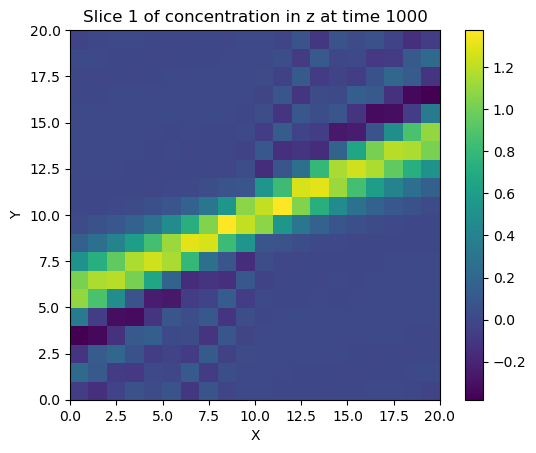

Wall time: 7.2532 s (0.0073 s/iter)
GPU-RAM currently allocated 0.06 MB (2.10 MB reserved)
GPU-RAM maximally allocated 0.09 MB (2.10 MB reserved)


In [13]:
%matplotlib inline

sim = mbs.PITTSolver(data, diffusivity=[1,0,0])
sim.solve(time_increment=1, max_iters=1000, frames=20, A=0.1, verbose='plot')

In [15]:
sim.electrolyte[0,9:12,9:12,0]

tensor([[1., 1., 0.],
        [1., 1., 0.],
        [0., 0., 0.]], device='cuda:0')

In [16]:
data.fields['concentration'][9:12,9:12,0]

array([[0.98297924, 0.9829793 , 0.9646615 ],
       [0.98297924, 0.9829793 , 0.9646615 ],
       [0.9646615 , 0.9646615 , 0.9634035 ]], dtype=float32)

In [72]:
import torch
import torch.nn.functional as F
from scipy.spatial.transform import Rotation as rot

diffusivity = [1,0,0]
size = 4

def gaussian_kernel_3d_torch(size=4, sigma=1.0):
    """Creates a 3D Gaussian kernel using PyTorch"""
    ax = torch.linspace(-(size // 2), size // 2, size)
    xx, yy, zz = torch.meshgrid(ax, ax, ax, indexing="ij")

    # Calculate Gaussian function for each point in the grid
    kernel = torch.exp(-(xx**2 + yy**2 + zz**2) / (2 * sigma**2))
    kernel /= kernel.sum()
    kernel = kernel.to(device)
    return kernel.unsqueeze(0).unsqueeze(0)

def rotate_crystal_diffusivity_to_reference(bunge_angles, convention='ZXZ', degrees=True):
    r_matrix = rot.from_euler(convention, bunge_angles, degrees=degrees).as_matrix()
    D_xyz = r_matrix @ D_material @ r_matrix.T
    return torch.tensor(D_xyz, dtype=precision, device=device)

data.add_field('concentration')
device = torch.device('cuda')
# check device is available
if torch.device(device).type.startswith('cuda') and not torch.cuda.is_available():
    device = torch.device('cpu')
    warnings.warn("CUDA not available, defaulting device to cpu. To avoid this warning, set device=torch.device('cpu')")
precision = torch.float32 # torch.float64

grains = torch.tensor(data.fields['grains'], dtype=precision, device=device)
elyte = (grains == 0).float()
elyte = elyte.unsqueeze(0)
c = torch.zeros_like(grains)

if not diffusivity:
    D_material = np.eye(3)
else:
    if not isinstance(diffusivity, (list, tuple)) or len(diffusivity) != 3:
        raise ValueError("Crystal diffusivity must be given as list [D_a, D_b, D_c]")
    D_material = np.eye(3)
    D_material[0,0] = diffusivity[0]
    D_material[1,1] = diffusivity[1]
    D_material[2,2] = diffusivity[2]

# Diffusivities and fluxes are defined at cell corners
# TODO: refactor this lengthy bit
Dxx = torch.zeros(data.Nx-1, data.Ny-1, data.Nz-1, dtype=precision, device=device)
Dxy = torch.zeros(data.Nx-1, data.Ny-1, data.Nz-1, dtype=precision, device=device)
Dxz = torch.zeros(data.Nx-1, data.Ny-1, data.Nz-1, dtype=precision, device=device)

if size % 2 > 0:
    warnings.warn("Kernel size must be even number")
pad_size = int((size-2)/2)
gaussian = gaussian_kernel_3d_torch(size=4, sigma=1)

if data.angles is None:
    raise ValueError("VoxelizedMeatball object has no grain orientations! Create orientations before trying to simulate.")

for i, label in enumerate(data.grain_ids):
    # sub_tensor, indices = self.crop_area_of_interest_torch(tensor, label)
    # Create binary mask for the label within the slice
    # mask = (sub_tensor == label).float()
    mask = (grains == label).float()
    mask = mask.unsqueeze(0).unsqueeze(0)
    mask = F.pad(mask, (pad_size,pad_size,pad_size,pad_size,pad_size,pad_size), mode='replicate')
    mask = F.conv3d(mask, gaussian, padding='valid')
    mask = mask.squeeze(0).squeeze(0)
    D_grain = rotate_crystal_diffusivity_to_reference(data.angles[i], convention='ZXZ', degrees=True)
    Dxx += mask*D_grain[0,0]
    Dxy += mask*D_grain[0,1]
    Dxz += mask*D_grain[0,2]

In [70]:
mask = (grains == label).float()
mask = mask.unsqueeze(0).unsqueeze(0)
mask = F.pad(mask, (pad_size,pad_size,pad_size,pad_size,pad_size,pad_size), mode='replicate')
mask = F.conv3d(mask, gaussian, padding='valid')
mask = mask.squeeze(0).squeeze(0)
mask.shape

torch.Size([19, 19, 1])

In [66]:
gaussian.shape

torch.Size([1, 1, 4, 4, 4])

In [52]:
rotate_crystal_diffusivity_to_reference([45,0,0], convention='ZXZ', degrees=True)

tensor([[0.5000, 0.5000, 0.0000],
        [0.5000, 0.5000, 0.0000],
        [0.0000, 0.0000, 0.0000]], device='cuda:0')

In [3]:
%matplotlib inline
# agglomerate.plot_slice('grains', 10)

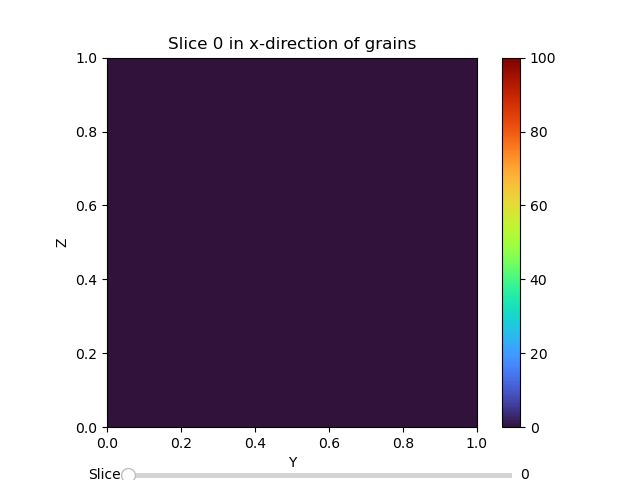

In [4]:
%matplotlib widget
agglomerate.plot_field_interactive("grains", direction='x', colormap='turbo')

In [3]:
radii = [20,50] # [20,50] #[50,80,110] #[30, 80, 100]
seed_nums = [50,100] # [50,100] #[100,150,400] #[50,300,50]

agglomerate.create_structured_agglomerate(radii, seed_nums)

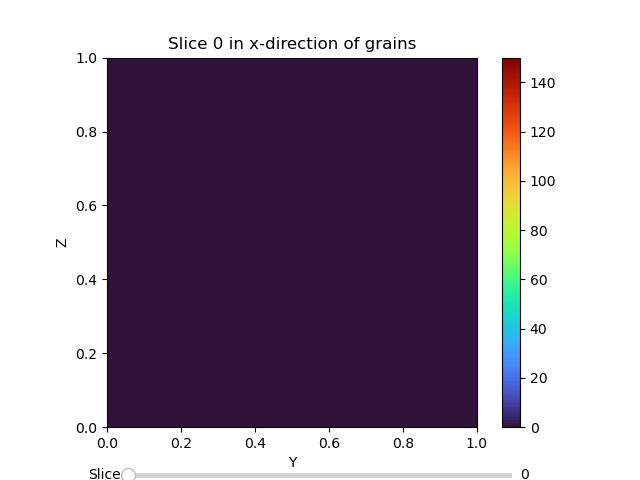

In [6]:
%matplotlib widget
agglomerate.plot_field_interactive("grains", direction='x', colormap='turbo')

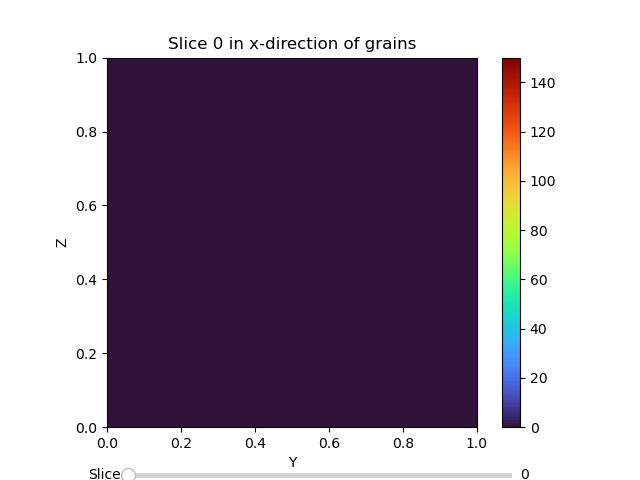

In [7]:
agglomerate.relabel_random_order()
%matplotlib widget
agglomerate.plot_field_interactive("grains", direction='x', colormap='turbo')

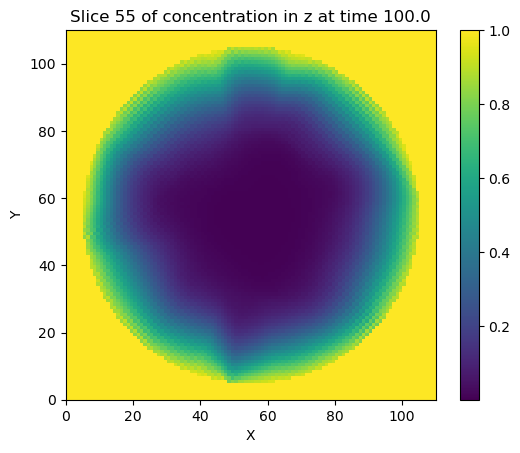

Wall time: 35.5728 s (0.0036 s/iter)
GPU-RAM currently allocated 69.15 MB (127.93 MB reserved)
GPU-RAM maximally allocated 85.16 MB (127.93 MB reserved)


In [4]:
%matplotlib inline
sim = mbs.PITTSolver(agglomerate, diffusivity=[1,1,0.1])
sim.solve(time_increment=0.01, max_iters=10000, frames=20, verbose='plot')

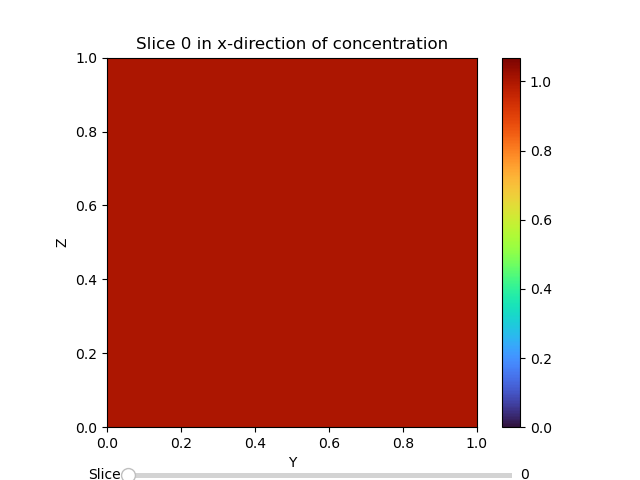

In [5]:
%matplotlib widget
agglomerate.plot_field_interactive("concentration", direction='x', colormap='turbo')

In [6]:
agglomerate.export_to_vtk("test_output.vtk")